#### 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
)

#### 2. Load and inspect

In [3]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ['pregnancies','glucose','blood_pressure','skin_thickness',
        'insulin','bmi','diabetes_pedigree','age','outcome']

df = pd.read_csv(url, names=cols)
print(df.shape)          # should be (768, 9)
print(df['outcome'].value_counts())  # class balance check
df.head()

(768, 9)
outcome
0    500
1    268
Name: count, dtype: int64


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


#### 3. Preprocess

In [4]:
# Separate features and label
X = df.drop('outcome', axis=1)
y = df['outcome']

# Split BEFORE scaling — never fit the scaler on the full dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale: fit only on train, apply to both
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)   # note: transform only, not fit_transform

#### 4. Train both models

In [5]:
lr  = LogisticRegression(max_iter=1000, random_state=42)
dt  = DecisionTreeClassifier(max_depth=5, random_state=42)

lr.fit(X_train_sc, y_train)
dt.fit(X_train_sc, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

* The first line just creates an empty tree structure. The second line — dt.fit(...) — is the fitting. That's where the tree actually learns its rules from your training data.

In [8]:
print("Depth:", dt.get_depth())
print("Leaves:", dt.get_n_leaves())

Depth: 5
Leaves: 20


* depth comes back as 5, the tree hit the ceiling I set — it wanted to keep growing but I stopped it. 

In [10]:
for depth in [3, 5, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train_sc, y_train)
    prob = model.predict_proba(X_test_sc)[:, 1]
    auc = roc_auc_score(y_test, prob)
    print(f"max_depth={str(depth):>4}  AUC-ROC={auc:.3f}  leaves={model.get_n_leaves()}")

max_depth=   3  AUC-ROC=0.788  leaves=7
max_depth=   5  AUC-ROC=0.784  leaves=20
max_depth=None  AUC-ROC=0.666  leaves=115


#### To see the overfit

In [11]:
for depth in [3, 5, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train_sc, y_train)
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train_sc)[:, 1])
    test_auc  = roc_auc_score(y_test,  model.predict_proba(X_test_sc)[:, 1])
    gap = train_auc - test_auc
    print(f"depth={depth!s:>4}  train={train_auc:.3f}  test={test_auc:.3f}  gap={gap:.3f}")

depth=   3  train=0.821  test=0.788  gap=0.033
depth=   5  train=0.888  test=0.784  gap=0.105
depth=None  train=1.000  test=0.666  gap=0.334


#### The gap column is the overfitting diagnostic.

#####  A well-behaved model has a small gap. You'll see the gap grow as depth increases — the model gets better and better on training data while getting worse on test data. That's the core bias-variance tradeoff: a model that overfits training data would perform well in the hospital that generated the training records, and worse when deployed elsewhere. That's a real problem in medical AI.

#### 5. Evaluate and build the comparison table

In [6]:
def evaluate(name, model, X, y_true):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 3),
        'Precision': round(precision_score(y_true, y_pred), 3),
        'Recall':    round(recall_score(y_true, y_pred), 3),
        'F1':        round(f1_score(y_true, y_pred), 3),
        'AUC-ROC':   round(roc_auc_score(y_true, y_prob), 3),
    }

results = pd.DataFrame([
    evaluate('Logistic Regression', lr, X_test_sc, y_test),
    evaluate('Decision Tree',       dt, X_test_sc, y_test),
])
results

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Logistic Regression,0.714,0.609,0.519,0.560,0.823
1,Decision Tree,0.792,0.704,0.704,0.704,0.784


#####  * logistic regression wins on AUC-ROC by a large margin even though accuracy is similar. That's because AUC-ROC measures the model's ability to rank patients by risk across all thresholds — it's a much richer signal than a single accuracy number. This is exactly why you'd report AUC-ROC in a clinical context.

##### * A decision tree with equal precision and recall sits at a perfectly symmetric operating point — it's making exactly as many false positives as false negatives. * "in a screening context this symmetry is not necessarily desirable — you'd want to deliberately bias the model toward higher recall, accepting more false alarms, because missing a diabetic patient has greater clinical cost than a false positive."

##### * Despite lower accuracy, logistic regression is the preferred model for a screening context. Its AUC-ROC of 0.823 vs 0.784 means it better discriminates diabetic from non-diabetic patients across all thresholds. The decision tree's accuracy advantage likely reflects the class imbalance — it predicts the majority class more often.

#### 6. Confusion matrices side by side

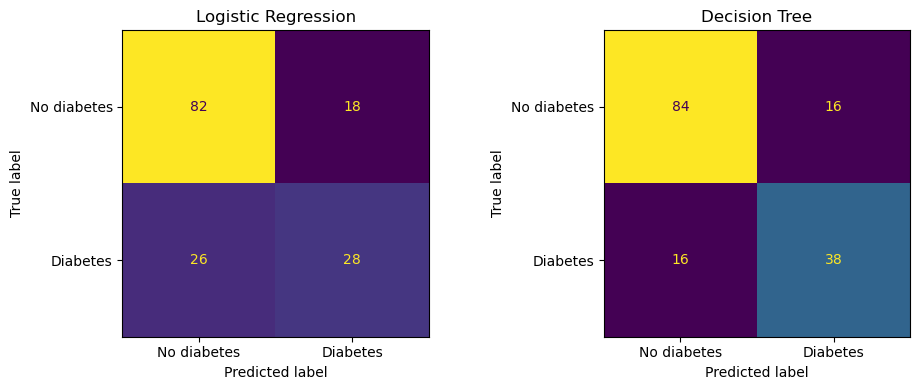

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, model, name in zip(axes,
                            [lr, dt],
                            ['Logistic Regression', 'Decision Tree']):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test_sc, y_test,
        display_labels=['No diabetes', 'Diabetes'],
        ax=ax, colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()